# Introducing Raygun Graphs

Raygun graphs are a new method for visualizing timelines of activity in collaborative insight generation processes. While they are flexible and could be applied to any context where multiple streams of action meed to be accounted for, they were developed to visualize different "epistemic" and "pragmatic" actions in a user study.

The visual style is inspired by raygun illustrations from 1950/60s comics.

In this example, we use data from a user study in which pairs of mixed-expertise users were given analysis tasks to carry out on a large multi-surface system. The actions of each user are coded as either "pragmatic" or "epistemic."

We use this distinction between pragmatic and epistemic actions to analyze and understand specific user interactions. Epistemic actions help users reduce cognitive load through alterations in their world that lead to a decrease in task complexity (e.g., modifying a visualization), and play an important role in problem-solving tasks. In contrast, pragmatic actions are definitive and directly bring the user closer to their goal. For this reason, researchers have suggested that classifying the actions users
make with a system as either epistemic or pragmatic can help in understanding how well the system supports problem solving. We analyzed user interactions with our system to understand if and how users make use of epistemic vs. pragmatic actions in their analyses.

See the following for more information on how this framework can be used to evaluate actions in a user study:
- David Kirsh and Paul Maglio. 1994. On distinguishing epistemic from pragmatic action. Cognitive science 18, 4 (1994),
513–549.
- Alissa N Antle and Sijie Wang. 2013. Comparing motor-cognitive strategies for spatial problem solving with tangible
and multi-touch interfaces. In Proceedings of the 7th International Conference on tangible, embedded and embodied
interaction. 65–72.
- Augusto Esteves, Saskia Bakker, Alissa N Antle, Aaron May, Jillian Warren, and Ian Oakley. 2015. The ATB framework:
Quantifying and classifying epistemic strategies in tangible problem-solving tasks. In Proceedings of the Ninth
International Conference on Tangible, Embedded, and Embodied Interaction. 13–20.

In this example, we'll use the basic dataset that collected user interactions, and simple matplotlib functions to demonstrate how raygun graphs can be used to visualize their actions.  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams['axes.axisbelow'] = True # place grid behind other graph elements
plt.rcParams['figure.figsize'] = [10, 7]

In [3]:
# task 1, user 1
df = pd.read_csv('analysis.csv')

In [4]:
df.head(5)

,user,actions,value,width,x,y,color
0,U1,4 PE,4,79.272727,39.636364,-2.0,#00429d
1,U1,1 PA,1,19.818182,89.181818,-0.5,#3e67ae
2,U1,2 PE,2,39.636364,118.909091,-1.0,#00429d
3,U1,1 PA,1,19.818182,148.636364,-0.5,#3e67ae
4,U1,2 PE,2,39.636364,178.363636,-1.0,#00429d


In [32]:
df['category'] = df['actions'].str.strip().str.extract(r'([A-Za-z]+)$')

color_map = {
    'EA': '#b81828',
    'PA': '#2166ac',
    'EE': '#d6604d',
    'PE': '#4393c3',
    'notes': '#d0d3b3',
    'ET': '#f4a582',
    'PT': '#92c5de',
}

df['color'] = df['category'].map(color_map)

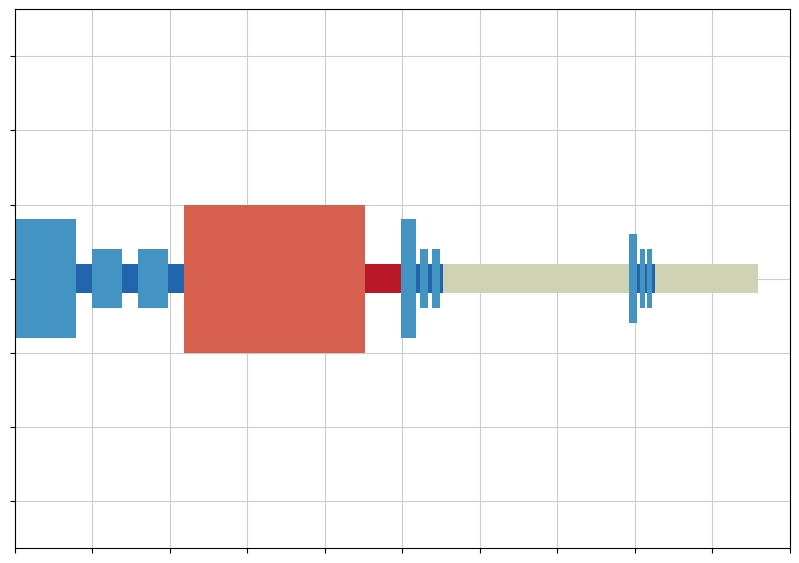

In [31]:
heights = df['value']
width = df['width']
y_pos = df['x']
bottom = df['y']
color = df['color']

fig, ax = plt.subplots()

ax.bar(y_pos, heights, width=width, color=color, bottom=bottom)
half_range = max(heights) / .55
ax.set_ylim(-half_range, half_range)
ax.set_xlim(0, 1000)
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.grid(color='0.8')
ax.tick_params(labelbottom=False, labelleft=False)

plt.show()
#plt.savefig('Task2Team1User1.png')

Completed, and arranged as small multiples with a clear legend, raygun diagrams present a unique way for understanding when specific users engaged in pragmatic events and pragmatic actions.

![image](rayguns.png)